# 05 - Customer Segmentation

TODO:
1. Load cleaned dataset from `data/processed/`
2. Calculate RFM metrics (Recency, Frequency, Monetary) per customer
3. Score and bucket customers into RFM segments
4. Profile each segment (size, revenue contribution, behavior)
5. Visualize segments and summarize actionable insights

_Note: clustering-based segmentation (K-Means) was explored and intentionally dropped in favor of the RFM-tier approach above — out of scope for this project._

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

### Load Data
`customer_df` from `data/processed/`.

In [2]:
customer_df = pd.read_csv('../data/processed/customer_df.csv', encoding='unicode_escape')
customer_df['InvoiceDate'] = pd.to_datetime(customer_df['InvoiceDate'])

# RFM Metrics
Recency, Frequency, Monetary — one row per customer, non-cancelled activity only.

### Recency
Days since each customer's most recent non-cancelled purchase, relative to a fixed reference date (e.g. one day after the dataset's last invoice date).

In [3]:
last_purchase_date = customer_df[~customer_df['is_cancelled']].groupby('Customer ID').agg({'InvoiceDate': 'max'})['InvoiceDate']
reference_date = customer_df['InvoiceDate'].max()
customer_recency = (reference_date - last_purchase_date).dt.days.reset_index(name='Customer_recency')

customer_recency

,Customer ID,Customer_recency
0,12346,325
1,12347,1
2,12348,74
3,12349,18
4,12350,309
...,...,...
4334,18280,277
4335,18281,180
4336,18282,7
4337,18283,3


### Frequency
Distinct non-cancelled orders per customer (same metric as `orders_per_customer` from 02/03).

In [4]:
customer_frequency = pd.read_csv('../data/processed/orders_per_customer.csv').rename(columns={'Number_of_Orders': 'Customer_frequency'})
customer_frequency

,Customer ID,Customer_frequency
0,12346,1
1,12347,7
2,12348,4
3,12349,1
4,12350,1
...,...,...
4334,18280,1
4335,18281,1
4336,18282,2
4337,18283,16


### Monetary
Total non-cancelled revenue per customer (same metric as `revenue_per_customer` from 03).

In [5]:
customer_monetary = pd.read_csv('../data/processed/revenue_per_customer.csv').rename(columns={'line_revenue': 'Customer_monetary'})
customer_monetary

,Customer ID,Customer_monetary
0,12346,77183.60
1,12347,4310.00
2,12348,1797.24
3,12349,1757.55
4,12350,334.40
...,...,...
4334,18280,180.60
4335,18281,80.82
4336,18282,178.05
4337,18283,2045.53


### Combine into One RFM Table
One row per customer with Recency, Frequency, and Monetary side by side.

In [6]:
rfm_table = customer_recency.merge(customer_frequency, on='Customer ID').merge(customer_monetary, on='Customer ID')
rfm_table

,Customer ID,Customer_recency,Customer_frequency,Customer_monetary
0,12346,325,1,77183.60
1,12347,1,7,4310.00
2,12348,74,4,1797.24
3,12349,18,1,1757.55
4,12350,309,1,334.40
...,...,...,...,...
4334,18280,277,1,180.60
4335,18281,180,1,80.82
4336,18282,7,2,178.05
4337,18283,3,16,2045.53


# RFM Scoring
Bucket each metric into quantiles (e.g. 1–5) so R, F, and M are on a comparable scale.

### Explore Extreme-Value Customers
Before formal scoring: who qualifies as a top customer simultaneously on Recency, Frequency, *and* Monetary, at strict percentile thresholds?

**Top 5%** — customers in the best 5% on all three metrics at once (recency ≤ 5th pct, frequency & monetary ≥ 95th pct).

In [7]:
print('Top 5% recency quantile:', rfm_table['Customer_recency'].quantile(q = 0.05))
print('Top 5% shopping frequency quantile:', rfm_table['Customer_frequency'].quantile(q = 0.95))
print('Top 5% purchase amount quantile:', rfm_table['Customer_monetary'].quantile(q = 0.95))

sel_data_5qr = rfm_table['Customer_recency'] <= rfm_table['Customer_recency'].quantile(q = 0.05)
sel_data_5qf = rfm_table['Customer_frequency'] >= rfm_table['Customer_frequency'].quantile(q = 0.95)
sel_data_5qm = rfm_table['Customer_monetary'] >= rfm_table['Customer_monetary'].quantile(q = 0.95)
data_5rfm = rfm_table[sel_data_5qr & sel_data_5qf & sel_data_5qm]
data_5rfm

Top 5% recency quantile: 2.0
Top 5% shopping frequency quantile: 13.0
Top 5% purchase amount quantile: 5787.24299999997


,Customer ID,Customer_recency,Customer_frequency,Customer_monetary
100,12471,1,30,19788.65
189,12583,2,15,7281.38
223,12621,1,20,13689.67
326,12748,0,210,33053.19
492,12989,2,15,6924.11
555,13078,2,26,12627.94
562,13089,2,97,58762.08
570,13098,0,28,28882.44
573,13102,0,24,6424.09
581,13113,0,24,12245.96


Frequency vs. Monetary, all customers vs. the top-5% group highlighted.

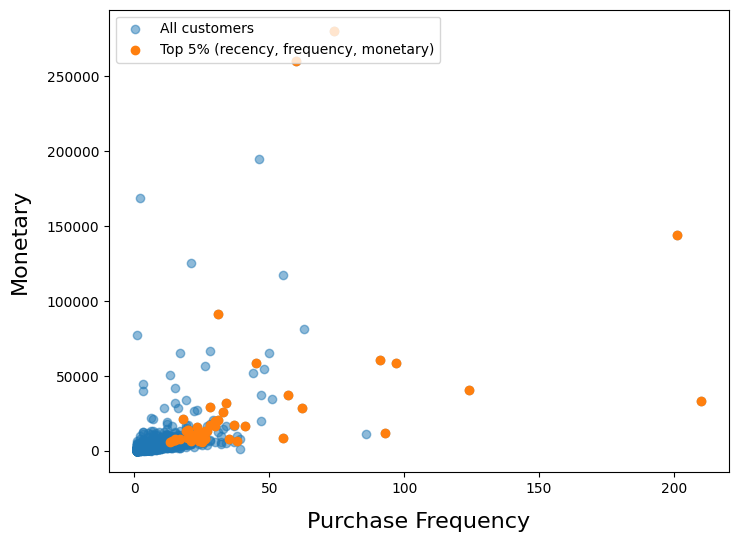

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(rfm_table['Customer_frequency'], rfm_table['Customer_monetary'],
           alpha=0.5, label='All customers')
ax.scatter(data_5rfm['Customer_frequency'], data_5rfm['Customer_monetary'],
           label='Top 5% (recency, frequency, monetary)')

ax.set_xlabel('Purchase Frequency', fontsize=16, labelpad=12)
ax.set_ylabel('Monetary', fontsize=16, labelpad=12)
ax.legend(loc='upper left')
plt.show()

**Top 1%** — same idea, tighter threshold (recency ≤ 1st pct, frequency & monetary ≥ 99th pct).

In [9]:
print('Top 1% recency quantile:', rfm_table['Customer_recency'].quantile(q = 0.01))
print('Top 1% shopping frequency quantile:', rfm_table['Customer_frequency'].quantile(q = 0.99))
print('Top 1% purchase amount quantile:', rfm_table['Customer_monetary'].quantile(q = 0.99))

sel_data_1qr = rfm_table['Customer_recency'] <= rfm_table['Customer_recency'].quantile(q = 0.01)
sel_data_1qf = rfm_table['Customer_frequency'] >= rfm_table['Customer_frequency'].quantile(q = 0.99)
sel_data_1qm = rfm_table['Customer_monetary'] >= rfm_table['Customer_monetary'].quantile(q = 0.99)
data_1rfm = rfm_table[sel_data_1qr & sel_data_1qf & sel_data_1qm]
data_1rfm

Top 1% recency quantile: 0.0
Top 1% shopping frequency quantile: 30.0
Top 1% purchase amount quantile: 19780.2672


,Customer ID,Customer_recency,Customer_frequency,Customer_monetary
326,12748,0,210,33053.19
1059,13777,0,33,25977.16
1070,13798,0,57,37153.85
1880,14911,0,201,143711.17
2177,15311,0,91,60632.75
3684,17389,0,34,31833.68
3895,17675,0,31,20374.28
4094,17949,0,45,58510.48
4202,18102,0,60,259657.30


Same scatter, narrowed to the top-1% group — a small, extreme-value core within the top-5% group above.

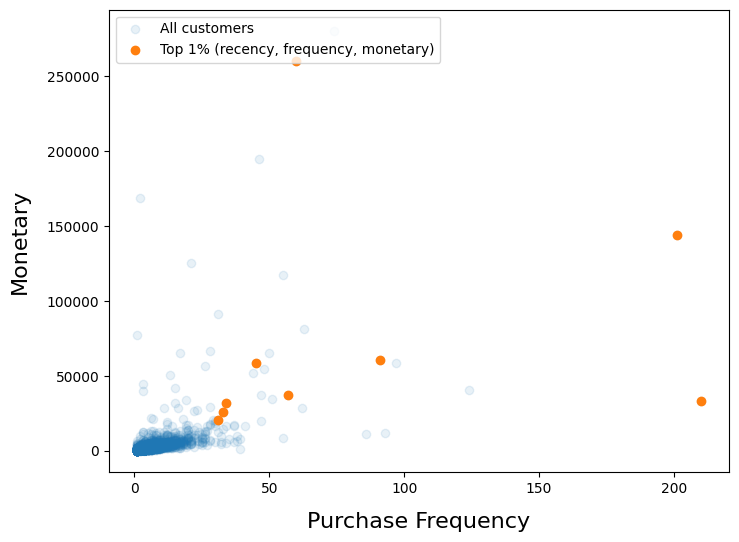

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(rfm_table['Customer_frequency'], rfm_table['Customer_monetary'],
           alpha=0.1, label='All customers')
ax.scatter(data_1rfm['Customer_frequency'], data_1rfm['Customer_monetary'],
           label='Top 1% (recency, frequency, monetary)')

ax.set_xlabel('Purchase Frequency', fontsize=16, labelpad=12)
ax.set_ylabel('Monetary', fontsize=16, labelpad=12)
ax.legend(loc='upper left')
plt.show()

### Score Each Metric (Terciles)
Rank each metric first (`.rank(method='first')`) so every value is unique before `qcut` — avoids duplicate bin-edge errors. Recency's labels are reversed (`[3,2,1]`) since low days = good; Frequency/Monetary use ascending labels since higher = good.

In [11]:
range_labels = list(range(3, 0, -1))
data_q=rfm_table.copy(deep=True)
data_q['recency_quartile']=pd.qcut(data_q['Customer_recency'].rank(method='first'), q=3, labels=range_labels)
data_q['frequency_quartile']=pd.qcut(data_q['Customer_frequency'].rank(method='first'), q=3, labels=range(1,4))
data_q['monetary_quartile']=pd.qcut(data_q['Customer_monetary'].rank(method='first'), q=3, labels=range(1,4))
data_q.head()

,Customer ID,Customer_recency,Customer_frequency,Customer_monetary,recency_quartile,frequency_quartile,monetary_quartile
0,12346,325,1,77183.60,1,1,3
1,12347,1,7,4310.00,3,3,3
2,12348,74,4,1797.24,2,2,3
3,12349,18,1,1757.55,3,1,3
4,12350,309,1,334.40,1,1,1


### RFM Score
Sum the three tercile scores (1–3 each) into one number per customer (range 3–9).

In [12]:
data_q['rfm_score'] = data_q[['recency_quartile','frequency_quartile','monetary_quartile']].sum(axis=1)
data_q.head()

,Customer ID,Customer_recency,Customer_frequency,Customer_monetary,recency_quartile,frequency_quartile,monetary_quartile,rfm_score
0,12346,325,1,77183.60,1,1,3,5
1,12347,1,7,4310.00,3,3,3,9
2,12348,74,4,1797.24,2,2,3,7
3,12349,18,1,1757.55,3,1,3,7
4,12350,309,1,334.40,1,1,1,3


### Segment Label String
Concatenate the three tercile scores into one label per customer (e.g. `"333"` = best on all three, `"111"` = worst on all three).

In [13]:
data_cat = (data_q['recency_quartile'].astype(str)).str.cat(data_q['frequency_quartile'].astype(str))
data_q['rfm_segment']=data_cat.str.cat(data_q['monetary_quartile'].astype(str))
data_q.head()

,Customer ID,Customer_recency,Customer_frequency,Customer_monetary,recency_quartile,frequency_quartile,monetary_quartile,rfm_score,rfm_segment
0,12346,325,1,77183.60,1,1,3,5,113
1,12347,1,7,4310.00,3,3,3,9,333
2,12348,74,4,1797.24,2,2,3,7,223
3,12349,18,1,1757.55,3,1,3,7,313
4,12350,309,1,334.40,1,1,1,3,111


### Named Tiers
Collapse `rfm_score` into three simple labels: Top (≥7), Middle (4–6), Low (≤3).

In [14]:
def rfm_level(df):
    if df['rfm_score'] >= 7:
        return 'Top'
    elif ((df['rfm_score'] >= 4) and (df['rfm_score'] < 7)):
        return 'Middle'
    else:
        return 'Low'
data_q['rfm_level'] = data_q.apply(rfm_level, axis=1)
data_q.head()

,Customer ID,Customer_recency,Customer_frequency,Customer_monetary,recency_quartile,frequency_quartile,monetary_quartile,rfm_score,rfm_segment,rfm_level
0,12346,325,1,77183.60,1,1,3,5,113,Middle
1,12347,1,7,4310.00,3,3,3,9,333,Top
2,12348,74,4,1797.24,2,2,3,7,223,Top
3,12349,18,1,1757.55,3,1,3,7,313,Top
4,12350,309,1,334.40,1,1,1,3,111,Low


### Tier Averages
Mean R/F/M and customer count per tier.

In [15]:

rfm_level_agg = data_q.groupby('rfm_level').agg({
    'Customer_recency': 'mean',
    'Customer_frequency': 'mean',
    'Customer_monetary': 'mean',
    'Customer ID': 'count'
}).round(2)
rfm_level_agg.head()

,Customer_recency,Customer_frequency,Customer_monetary,Customer ID
rfm_level,,,,
Low,244.00,1.00,199.98,626
Middle,102.77,1.82,651.92,1910
Top,26.66,8.00,4169.09,1803


### Revenue Concentration by Tier
What % of customers vs. what % of total revenue each tier represents — the key number behind the Actionable Insights below.

In [16]:
tier_summary = data_q.groupby('rfm_level').agg(
    customers=('Customer ID', 'count'),
    revenue=('Customer_monetary', 'sum'),
)
tier_summary['pct_customers'] = (tier_summary['customers'] / tier_summary['customers'].sum() * 100).round(1)
tier_summary['pct_revenue'] = (tier_summary['revenue'] / tier_summary['revenue'].sum() * 100).round(1)
tier_summary

,customers,revenue,pct_customers,pct_revenue
rfm_level,,,,
Low,626,125186.030,14.4,1.4
Middle,1910,1245170.323,44.0,14.0
Top,1803,7516870.541,41.6,84.6


# Segment Profiling
Size, revenue contribution, and typical behavior per segment (RFM-tier or cluster, whichever you used above).

### Revenue Share Chart
Visualizing `tier_summary` from above.

<Axes: title={'center': 'Revenue by RFM Tier'}, xlabel='RFM Tier', ylabel='Revenue (%)'>

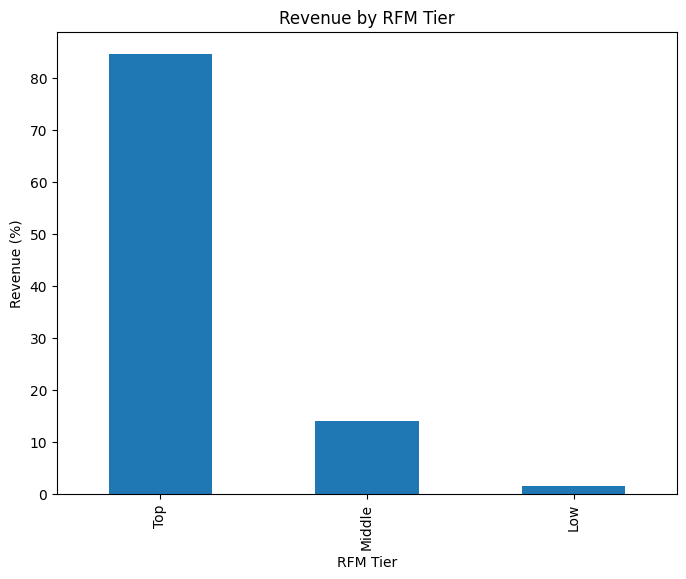

In [17]:
tier_summary.sort_values(by='pct_revenue', ascending=False).plot(
    kind='bar',
    y='pct_revenue',
    title='Revenue by RFM Tier',
    xlabel='RFM Tier',
    ylabel='Revenue (%)',
    legend=False,
    figsize=(8, 6))

### Relative to Average
Each tier's R/F/M as a multiple of the overall average — makes "Top spends 2x average" explicit instead of raw numbers.

In [18]:
metrics = ['Customer_recency', 'Customer_frequency', 'Customer_monetary']
overall_avg = data_q[metrics].mean()
relative_to_avg = rfm_level_agg[metrics].div(overall_avg)
relative_to_avg['Customer_recency'] = overall_avg['Customer_recency'] / rfm_level_agg['Customer_recency'] #because its inverted
relative_to_avg.round(2)

,Customer_recency,Customer_frequency,Customer_monetary
rfm_level,,,
Low,0.38,0.23,0.10
Middle,0.89,0.43,0.32
Top,3.43,1.87,2.04


# Visualize Segments

### Segment Sizes
Bar chart of customer count per segment.

<Axes: title={'center': 'Customer Count by RFM Tier'}, xlabel='RFM Tier', ylabel='Customer Count'>

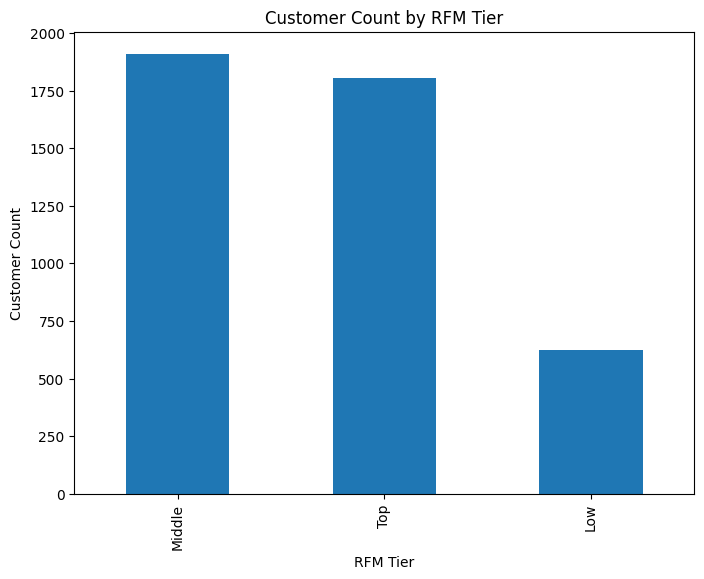

In [19]:
data_q['rfm_level'].value_counts().plot(
    kind='bar',
    title='Customer Count by RFM Tier',
    xlabel='RFM Tier',
    ylabel='Customer Count',
    legend=False,
    figsize=(8, 6))

### Segments in RFM Space
Scatter plot (e.g. Recency vs. Monetary, colored by segment) to see how segments separate visually.

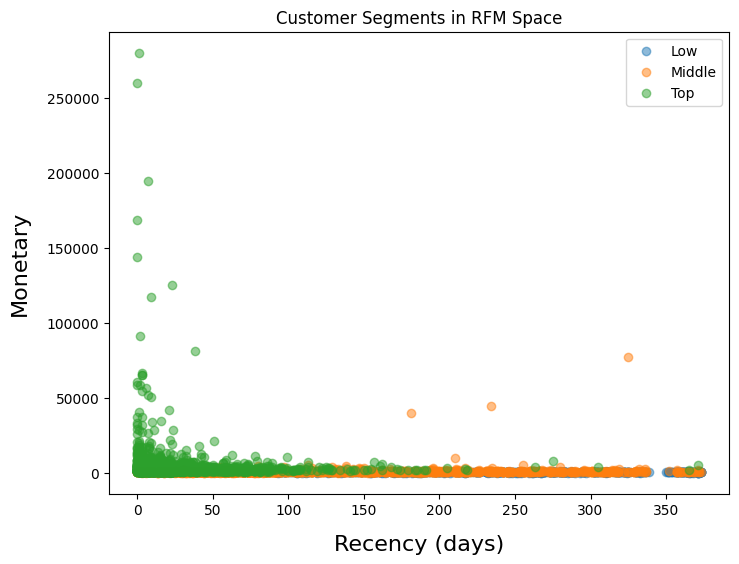

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))

for level in ['Low', 'Middle', 'Top']:
    subset = data_q[data_q['rfm_level'] == level]
    ax.scatter(subset['Customer_recency'], subset['Customer_monetary'], alpha=0.5, label=level)

ax.set_xlabel('Recency (days)', fontsize=16, labelpad=12)
ax.set_ylabel('Monetary', fontsize=16, labelpad=12)
ax.set_title('Customer Segments in RFM Space')
ax.legend(loc='upper right')
plt.show()

# Actionable Insights
Takeaways per segment — e.g. who to target for retention, who's already loyal, who's at risk of churning.

1. **Top tier — early access, order-history-based perks.** 1,803 customers (~42%) generate ~85% of revenue, and they're already frequent (avg. 8 orders) and recent (avg. 27 days). *Why:* this tier is concentrated, not diversified — losing even a small slice of it hurts more than any acquisition effort helps. The goal isn't winning them over, it's keeping them engaged, so perks should reward existing behavior (early access to new stock, rewards tied to their own order history) rather than trying to convert them further.

2. **Middle tier — reminder emails timed to their historical purchase gap, post-purchase follow-ups, or a subscribe-and-save incentive.** ~1,910 customers, moderate spend (avg. £652), low frequency (avg. ~1.8 orders). *Why:* revenue per line item stays flat regardless of cohort (04), so the lever here is purchase *frequency*, not basket size — nudges timed to when a customer is statistically due to reorder (rather than generic blanket promos) target the actual gap without discounting unnecessarily.

3. **Low tier — a time-limited second-order discount.** 626 customers, ~1 order each, contributing only 1.4% of revenue. *Why:* this looks like "tried once and left," not "loyal but small" — and cohort retention (04) shows most cohorts lose 75%+ of new customers by month 1. A discount aimed specifically at securing the *second* purchase targets that exact drop-off point, rather than discounting broadly across a tier that may simply not convert to repeat buyers regardless.